# XGBoost Analysis For GMS Prediction (Time-Binned Dataset)

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/time_binned_dataset.csv")

print("Shape:", df.shape)
df.head()

Shape: (87649, 58)


,datetime,bz_gsm_nt_mean,bz_gsm_nt_min,bz_gsm_nt_max,bz_gsm_nt_last,bz_gsm_nt_trend,b_magnitude_avg_nt_mean,b_magnitude_avg_nt_min,b_magnitude_avg_nt_max,b_magnitude_avg_nt_last,...,ap_27d_ago,speed_27d_ago,ap_target_3h,storm_3h,ap_target_6h,storm_6h,ap_target_12h,storm_12h,ap_target_24h,storm_24h
0,1995-01-01 00:00:00,NaN,NaN,NaN,-0.633333,NaN,NaN,NaN,NaN,3.400000,...,NaN,NaN,0.0,0,3.0,0,2.0,0,5.0,0
1,1995-01-01 03:00:00,NaN,NaN,NaN,0.533333,NaN,NaN,NaN,NaN,4.533333,...,NaN,NaN,3.0,0,5.0,0,4.0,0,9.0,0
2,1995-01-01 06:00:00,NaN,NaN,NaN,0.500000,NaN,NaN,NaN,NaN,4.300000,...,NaN,NaN,5.0,0,2.0,0,12.0,0,12.0,0
3,1995-01-01 09:00:00,-0.366667,-1.866667,0.533333,-1.866667,NaN,4.158333,3.4,4.533333,4.400000,...,NaN,NaN,2.0,0,4.0,0,3.0,0,18.0,0
4,1995-01-01 12:00:00,-0.060000,-1.866667,1.166667,1.166667,NaN,4.013333,3.4,4.533333,3.433333,...,NaN,NaN,4.0,0,12.0,0,5.0,0,9.0,0


In [7]:
df.columns.tolist()

['datetime',
 'bz_gsm_nt_mean',
 'bz_gsm_nt_min',
 'bz_gsm_nt_max',
 'bz_gsm_nt_last',
 'bz_gsm_nt_trend',
 'b_magnitude_avg_nt_mean',
 'b_magnitude_avg_nt_min',
 'b_magnitude_avg_nt_max',
 'b_magnitude_avg_nt_last',
 'b_magnitude_avg_nt_trend',
 'flow_speed_kms_mean',
 'flow_speed_kms_min',
 'flow_speed_kms_max',
 'flow_speed_kms_last',
 'flow_speed_kms_trend',
 'proton_density_cm3_mean',
 'proton_density_cm3_min',
 'proton_density_cm3_max',
 'proton_density_cm3_last',
 'proton_density_cm3_trend',
 'flow_pressure_npa_mean',
 'flow_pressure_npa_min',
 'flow_pressure_npa_max',
 'flow_pressure_npa_last',
 'flow_pressure_npa_trend',
 'electric_field_mvpm_mean',
 'electric_field_mvpm_min',
 'electric_field_mvpm_max',
 'electric_field_mvpm_last',
 'electric_field_mvpm_trend',
 'bz_south_mean',
 'bz_south_max',
 'bz_south_last',
 'coupling_mean',
 'coupling_max',
 'flare_count_win',
 'flare_max_class_now',
 'cme_count_72h',
 'cme_earthdir_count_72h',
 'cme_max_speed_72h',
 'cme_max_half_angl

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87649 entries, 0 to 87648
Data columns (total 58 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   datetime                   87649 non-null  object 
 1   bz_gsm_nt_mean             87609 non-null  float64
 2   bz_gsm_nt_min              87609 non-null  float64
 3   bz_gsm_nt_max              87609 non-null  float64
 4   bz_gsm_nt_last             87586 non-null  float64
 5   bz_gsm_nt_trend            87527 non-null  float64
 6   b_magnitude_avg_nt_mean    87609 non-null  float64
 7   b_magnitude_avg_nt_min     87609 non-null  float64
 8   b_magnitude_avg_nt_max     87609 non-null  float64
 9   b_magnitude_avg_nt_last    87588 non-null  float64
 10  b_magnitude_avg_nt_trend   87531 non-null  float64
 11  flow_speed_kms_mean        87596 non-null  float64
 12  flow_speed_kms_min         87596 non-null  float64
 13  flow_speed_kms_max         87596 non-null  flo

In [8]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
datetime,87649,87649,1995-01-01 00:00:00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bz_gsm_nt_mean,87609.0,NaN,NaN,NaN,-0.062075,1.656134,-16.4125,-0.833333,-0.075,0.7,13.958333
bz_gsm_nt_min,87609.0,NaN,NaN,NaN,-2.622715,2.639565,-48.466667,-3.4,-2.1,-1.133333,7.966667
bz_gsm_nt_max,87609.0,NaN,NaN,NaN,2.48699,2.515971,-12.933333,1.0,1.966667,3.3,35.133333
bz_gsm_nt_last,87586.0,NaN,NaN,NaN,-0.062089,2.647114,-48.466667,-1.3,-0.066667,1.166667,35.133333
bz_gsm_nt_trend,87527.0,NaN,NaN,NaN,0.000771,3.620468,-50.566667,-1.666667,0.0,1.6,47.933333
b_magnitude_avg_nt_mean,87609.0,NaN,NaN,NaN,5.771595,2.545877,1.191667,4.05,5.245833,6.845833,34.725
b_magnitude_avg_nt_min,87609.0,NaN,NaN,NaN,4.27178,1.799083,0.6,3.0,3.966667,5.166667,23.7
b_magnitude_avg_nt_max,87609.0,NaN,NaN,NaN,7.586044,4.025046,1.466667,5.033333,6.566667,8.966667,56.666667
b_magnitude_avg_nt_last,87588.0,NaN,NaN,NaN,5.771794,2.992078,0.6,3.866667,5.1,6.833333,56.666667


In [9]:
df["datetime"] = pd.to_datetime(df["datetime"])
df = df.sort_values("datetime").reset_index(drop=True)

print("Shape:", df.shape)
print("Date range:", df["datetime"].min(), "to", df["datetime"].max())

df[["datetime", "ap_now", "ap_target_3h", "storm_3h", "ap_target_6h", "storm_6h"]].head()

Shape: (87649, 58)
Date range: 1995-01-01 00:00:00 to 2024-12-30 00:00:00


,datetime,ap_now,ap_target_3h,storm_3h,ap_target_6h,storm_6h
0,1995-01-01 00:00:00,4.0,0.0,0,3.0,0
1,1995-01-01 03:00:00,0.0,3.0,0,5.0,0
2,1995-01-01 06:00:00,3.0,5.0,0,2.0,0
3,1995-01-01 09:00:00,5.0,2.0,0,4.0,0
4,1995-01-01 12:00:00,2.0,4.0,0,12.0,0


In [10]:
target_cols = ["storm_3h", "storm_6h", "storm_12h", "storm_24h"]

for col in target_cols:
    print(f"\n{col}")
    print(df[col].value_counts())
    print("Storm rate:", round(df[col].mean() * 100, 2), "%")


storm_3h
storm_3h
0    86043
1     1606
Name: count, dtype: int64
Storm rate: 1.83 %

storm_6h
storm_6h
0    86043
1     1606
Name: count, dtype: int64
Storm rate: 1.83 %

storm_12h
storm_12h
0    86043
1     1606
Name: count, dtype: int64
Storm rate: 1.83 %

storm_24h
storm_24h
0    86043
1     1606
Name: count, dtype: int64
Storm rate: 1.83 %


In [11]:
df[["storm_3h", "storm_6h", "storm_12h", "storm_24h"]].drop_duplicates().head(10)

,storm_3h,storm_6h,storm_12h,storm_24h
0,0,0,0,0
8,0,0,0,1
12,0,0,1,0
14,0,1,0,0
15,1,0,0,0
130,0,0,1,1
132,0,1,1,0
133,1,1,1,0
135,1,1,0,0
340,0,1,1,1


In [12]:
(df["storm_3h"] == df["storm_6h"]).mean(), (df["storm_3h"] == df["storm_12h"]).mean(), (df["storm_3h"] == df["storm_24h"]).mean()

(np.float64(0.9818822804595603),
 np.float64(0.9733254229939874),
 np.float64(0.9676208513502721))

In [13]:
# Check whether future Ap targets match shifted ap_now values
for hours in [3, 6, 12, 24]:
    steps = hours // 3
    target_col = f"ap_target_{hours}h"
    
    comparison = np.isclose(
        df[target_col].iloc[:-steps],
        df["ap_now"].shift(-steps).iloc[:-steps],
        equal_nan=True
    )
    
    print(f"{target_col} matches ap_now shifted by {steps} row(s):", comparison.mean())

ap_target_3h matches ap_now shifted by 1 row(s): 1.0
ap_target_6h matches ap_now shifted by 2 row(s): 1.0
ap_target_12h matches ap_now shifted by 4 row(s): 1.0
ap_target_24h matches ap_now shifted by 8 row(s): 1.0


In [15]:
for threshold in [27, 32, 39, 50, 56, 67, 100]:
    print(f"\nThreshold: ap > {threshold}")
    for hours in [3, 6, 12, 24]:
        target_col = f"ap_target_{hours}h"
        storm_col = f"storm_{hours}h"
        match_rate = (df[storm_col] == (df[target_col] > threshold).astype(int)).mean()
        print(f"{storm_col}: match rate = {match_rate:.4f}")


Threshold: ap > 27
storm_3h: match rate = 0.9623
storm_6h: match rate = 0.9623
storm_12h: match rate = 0.9623
storm_24h: match rate = 0.9623

Threshold: ap > 32
storm_3h: match rate = 0.9790
storm_6h: match rate = 0.9790
storm_12h: match rate = 0.9790
storm_24h: match rate = 0.9790

Threshold: ap > 39
storm_3h: match rate = 0.9918
storm_6h: match rate = 0.9918
storm_12h: match rate = 0.9918
storm_24h: match rate = 0.9918

Threshold: ap > 50
storm_3h: match rate = 1.0000
storm_6h: match rate = 1.0000
storm_12h: match rate = 1.0000
storm_24h: match rate = 1.0000

Threshold: ap > 56
storm_3h: match rate = 0.9943
storm_6h: match rate = 0.9943
storm_12h: match rate = 0.9943
storm_24h: match rate = 0.9943

Threshold: ap > 67
storm_3h: match rate = 0.9902
storm_6h: match rate = 0.9902
storm_12h: match rate = 0.9902
storm_24h: match rate = 0.9902

Threshold: ap > 100
storm_3h: match rate = 0.9858
storm_6h: match rate = 0.9858
storm_12h: match rate = 0.9858
storm_24h: match rate = 0.9858


In [16]:
df_2010 = df[df["datetime"] >= "2010-01-01"].copy()

print("Full dataset shape:", df.shape)
print("Full date range:", df["datetime"].min(), "to", df["datetime"].max())

print("\n2010 onward shape:", df_2010.shape)
print("2010 onward date range:", df_2010["datetime"].min(), "to", df_2010["datetime"].max())

print("\nStorm rate full:", round(df["storm_3h"].mean() * 100, 2), "%")
print("Storm rate 2010 onward:", round(df_2010["storm_3h"].mean() * 100, 2), "%")

Full dataset shape: (87649, 58)
Full date range: 1995-01-01 00:00:00 to 2024-12-30 00:00:00

2010 onward shape: (43817, 58)
2010 onward date range: 2010-01-01 00:00:00 to 2024-12-30 00:00:00

Storm rate full: 1.83 %
Storm rate 2010 onward: 1.26 %


In [17]:
missing_2010 = df_2010.isna().sum().sort_values(ascending=False)
missing_2010[missing_2010 > 0].head(15)

flare_count_win              20769
flare_max_class_now          20769
cme_max_speed_now              740
cme_count_24h                  740
cme_max_half_angle_72h         740
cme_max_speed_72h              740
cme_earthdir_count_72h         740
cme_count_72h                  740
proton_density_cm3_trend       179
flow_pressure_npa_trend        179
flow_pressure_npa_last          96
proton_density_cm3_last         96
electric_field_mvpm_trend       74
flow_speed_kms_trend            68
bz_gsm_nt_trend                 46
dtype: int64

Although the full time-binned dataset spans 1995–2024, this notebook uses the 2010 onward subset because the dataset quality check confirmed that the 3-hour grid is fully regular over 2010–2024. This subset also matches the finalized modeling dataset described by the team, with 43,817 rows and a storm rate of about 1.26%.

1. XGBClassifier: predict storm_3h
2. XGBRegressor: predict ap_target_3h

- time-aware train/test split
- storm class imbalance handling
- compare against persistence baseline
- start with 3h horizon first

In [20]:
df_model = df[df["datetime"] >= "2010-01-01"].copy()

print("Shape:", df_model.shape)
print("Date range:", df_model["datetime"].min(), "to", df_model["datetime"].max())

Shape: (43817, 58)
Date range: 2010-01-01 00:00:00 to 2024-12-30 00:00:00


In [18]:
# making XGBoost feature set
TARGET_CLASS = "storm_3h"
TARGET_REG = "ap_target_3h"

In [21]:
target_cols = [
    "ap_target_3h", "storm_3h",
    "ap_target_6h", "storm_6h",
    "ap_target_12h", "storm_12h",
    "ap_target_24h", "storm_24h",
]

non_feature_cols = ["datetime"] + target_cols

FEATURE_COLS = [col for col in df_model.columns if col not in non_feature_cols]

print("Number of features:", len(FEATURE_COLS))
FEATURE_COLS

Number of features: 49


['bz_gsm_nt_mean',
 'bz_gsm_nt_min',
 'bz_gsm_nt_max',
 'bz_gsm_nt_last',
 'bz_gsm_nt_trend',
 'b_magnitude_avg_nt_mean',
 'b_magnitude_avg_nt_min',
 'b_magnitude_avg_nt_max',
 'b_magnitude_avg_nt_last',
 'b_magnitude_avg_nt_trend',
 'flow_speed_kms_mean',
 'flow_speed_kms_min',
 'flow_speed_kms_max',
 'flow_speed_kms_last',
 'flow_speed_kms_trend',
 'proton_density_cm3_mean',
 'proton_density_cm3_min',
 'proton_density_cm3_max',
 'proton_density_cm3_last',
 'proton_density_cm3_trend',
 'flow_pressure_npa_mean',
 'flow_pressure_npa_min',
 'flow_pressure_npa_max',
 'flow_pressure_npa_last',
 'flow_pressure_npa_trend',
 'electric_field_mvpm_mean',
 'electric_field_mvpm_min',
 'electric_field_mvpm_max',
 'electric_field_mvpm_last',
 'electric_field_mvpm_trend',
 'bz_south_mean',
 'bz_south_max',
 'bz_south_last',
 'coupling_mean',
 'coupling_max',
 'flare_count_win',
 'flare_max_class_now',
 'cme_count_72h',
 'cme_earthdir_count_72h',
 'cme_max_speed_72h',
 'cme_max_half_angle_72h',
 'cme

In [22]:
# time-based train/test split 
TARGET_CLASS = "storm_3h"
TARGET_REG = "ap_target_3h"

split_date = "2022-01-01"

train_df = df_model[df_model["datetime"] < split_date].copy()
test_df = df_model[df_model["datetime"] >= split_date].copy()

X_train = train_df[FEATURE_COLS]
X_test = test_df[FEATURE_COLS]

y_train_class = train_df[TARGET_CLASS]
y_test_class = test_df[TARGET_CLASS]

y_train_reg = train_df[TARGET_REG]
y_test_reg = test_df[TARGET_REG]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain date range:", train_df["datetime"].min(), "to", train_df["datetime"].max())
print("Test date range:", test_df["datetime"].min(), "to", test_df["datetime"].max())

print("\nClassification target balance:")
print("Train:")
print(y_train_class.value_counts())
print("Train storm rate:", round(y_train_class.mean() * 100, 2), "%")

print("\nTest:")
print(y_test_class.value_counts())
print("Test storm rate:", round(y_test_class.mean() * 100, 2), "%")

Train shape: (35064, 49)
Test shape: (8753, 49)

Train date range: 2010-01-01 00:00:00 to 2021-12-31 21:00:00
Test date range: 2022-01-01 00:00:00 to 2024-12-30 00:00:00

Classification target balance:
Train:
storm_3h
0    34685
1      379
Name: count, dtype: int64
Train storm rate: 1.08 %

Test:
storm_3h
0    8579
1     174
Name: count, dtype: int64
Test storm rate: 1.99 %


### 1) XGBoost regression

In [23]:
# persistence baseline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Persistence baseline for 3-hour ahead Ap prediction
y_pred_persistence = test_df["ap_now"]

mae_persistence = mean_absolute_error(y_test_reg, y_pred_persistence)
rmse_persistence = mean_squared_error(y_test_reg, y_pred_persistence) ** 0.5
r2_persistence = r2_score(y_test_reg, y_pred_persistence)

print("Persistence Baseline — 3h Ap Prediction")
print(f"MAE : {mae_persistence:.3f}")
print(f"RMSE: {rmse_persistence:.3f}")
print(f"R²  : {r2_persistence:.3f}")

Persistence Baseline — 3h Ap Prediction
MAE : 5.256
RMSE: 11.253
R²  : 0.603


In [24]:
# XGBoost regression for ap_target_3h
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from xgboost import XGBRegressor

xgb_reg_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", XGBRegressor(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        objective="reg:squarederror",
        n_jobs=-1
    ))
])

xgb_reg_pipe.fit(X_train, y_train_reg)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('model',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsample_bytree=0.8, device=None,
                              early_stopping_rounds=None,
                              enable_categorical=False, eval_metric=None,
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=3, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=300, n_jobs=-1,
                              num_parallel_tree=None, ...))])

In [25]:
y_pred_xgb_reg = xgb_reg_pipe.predict(X_test)

mae_xgb = mean_absolute_error(y_test_reg, y_pred_xgb_reg)
rmse_xgb = mean_squared_error(y_test_reg, y_pred_xgb_reg) ** 0.5
r2_xgb = r2_score(y_test_reg, y_pred_xgb_reg)

print("XGBoost Regression — 3h Ap Prediction")
print(f"MAE : {mae_xgb:.3f}")
print(f"RMSE: {rmse_xgb:.3f}")
print(f"R²  : {r2_xgb:.3f}")

print("\nPersistence Baseline")
print(f"MAE : {mae_persistence:.3f}")
print(f"RMSE: {rmse_persistence:.3f}")
print(f"R²  : {r2_persistence:.3f}")

XGBoost Regression — 3h Ap Prediction
MAE : 5.032
RMSE: 12.274
R²  : 0.528

Persistence Baseline
MAE : 5.256
RMSE: 11.253
R²  : 0.603


### XGBoost Regression Results

The XGBoost regression model slightly improved MAE compared with the persistence baseline, but it performed worse on RMSE and R². This suggests that the model may predict common quiet-time Ap values reasonably well, but it struggles with larger Ap spikes and storm-level events. Since RMSE penalizes large errors more heavily than MAE, the worse RMSE indicates that the model is likely missing some extreme geomagnetic activity periods.

Overall, the initial XGBoost regression baseline did not clearly outperform persistence for 3-hour Ap forecasting. This shows that persistence is a strong baseline at short forecast horizons and that future work should focus on handling rare high-Ap events better, such as using target transformations, weighted losses, or storm-focused classification.

In [26]:
results_reg = test_df[["datetime", "ap_now", "ap_target_3h", "storm_3h"]].copy()
results_reg["xgb_pred_ap_3h"] = y_pred_xgb_reg
results_reg["persistence_pred_ap_3h"] = y_pred_persistence

results_reg["xgb_abs_error"] = (results_reg["ap_target_3h"] - results_reg["xgb_pred_ap_3h"]).abs()
results_reg["persistence_abs_error"] = (results_reg["ap_target_3h"] - results_reg["persistence_pred_ap_3h"]).abs()

print("Mean absolute error by actual storm label:")
print(
    results_reg.groupby("storm_3h")[["xgb_abs_error", "persistence_abs_error"]].mean()
)

Mean absolute error by actual storm label:
          xgb_abs_error  persistence_abs_error
storm_3h                                      
0              4.097793               4.459028
1             51.082778              44.545977


### Error Analysis by Storm Label

The XGBoost regression model performed better than the persistence baseline during non-storm periods, with lower mean absolute error for quiet-time bins. However, it performed worse during actual storm periods. For storm bins, XGBoost had a higher mean absolute error than persistence, suggesting that the model struggled to predict rare high-Ap spikes.

This explains why XGBoost slightly improved overall MAE but performed worse on RMSE and R². The model appears to fit the quiet majority better, but it does not yet capture extreme geomagnetic activity well enough. Since storm events are the most important cases for this project, future work should focus on storm-weighted training, target transformations, or classification models that explicitly prioritize rare storm events.

### 2) XGBoost classification

In [27]:
# XGBoost Classification
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)
from xgboost import XGBClassifier

negative_count = (y_train_class == 0).sum()
positive_count = (y_train_class == 1).sum()
scale_pos_weight = negative_count / positive_count

print("scale_pos_weight:", round(scale_pos_weight, 2))

scale_pos_weight: 91.52


In [28]:
xgb_clf_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    ))
])

xgb_clf_pipe.fit(X_train, y_train_class)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=0.8, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='logloss',
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=3, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [29]:
y_pred_class = xgb_clf_pipe.predict(X_test)
y_pred_prob = xgb_clf_pipe.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test_class, y_pred_prob)
pr_auc = average_precision_score(y_test_class, y_pred_prob)

print("XGBoost Classification — 3h Storm Prediction")
print(f"ROC-AUC : {roc_auc:.3f}")
print(f"PR-AUC  : {pr_auc:.3f}  (no-skill baseline = {y_test_class.mean():.3f})")
print()
print(classification_report(y_test_class, y_pred_class, target_names=["No storm", "Storm"]))

print("Confusion matrix:")
print(confusion_matrix(y_test_class, y_pred_class))

XGBoost Classification — 3h Storm Prediction
ROC-AUC : 0.965
PR-AUC  : 0.576  (no-skill baseline = 0.020)

              precision    recall  f1-score   support

    No storm       1.00      0.94      0.97      8579
       Storm       0.22      0.86      0.35       174

    accuracy                           0.94      8753
   macro avg       0.61      0.90      0.66      8753
weighted avg       0.98      0.94      0.95      8753

Confusion matrix:
[[8046  533]
 [  24  150]]


### XGBoost Classification Results

The XGBoost classification model performed much better than the earlier event-level models on the time-binned dataset. For 3-hour-ahead storm prediction, the model achieved a ROC-AUC of 0.965 and a PR-AUC of 0.576, which is far above the no-skill baseline of 0.020. This suggests that the time-binned features contain meaningful predictive signal for identifying storm conditions.

At the default threshold, the model caught 150 out of 174 storm bins, giving a storm recall of 0.86. However, storm precision was 0.22, meaning the model also produced many false alarms. This tradeoff may still be useful for an early-warning setting, where missing storms can be more costly than issuing extra warnings.

In [30]:
# Top features used by the XGBoost classifier
importances = pd.Series(
    xgb_clf_pipe.named_steps["model"].feature_importances_,
    index=FEATURE_COLS
).sort_values(ascending=False)

importances.head(15)

ap_now                      0.249516
ap_trend                    0.086352
b_magnitude_avg_nt_last     0.054114
ap_max                      0.044077
ap_mean                     0.030116
flow_pressure_npa_last      0.027888
cme_max_half_angle_72h      0.022770
b_magnitude_avg_nt_trend    0.022035
flow_pressure_npa_max       0.020041
cme_max_speed_72h           0.019596
electric_field_mvpm_last    0.018363
flow_pressure_npa_trend     0.018029
bz_gsm_nt_min               0.015311
bz_south_max                0.015291
bz_gsm_nt_last              0.014267
dtype: float32

In [31]:
# with stricter feature set excluding current/recent Ap features
AP_FEATURES_TO_REMOVE = ["ap_now", "ap_mean", "ap_max", "ap_trend"]

FEATURE_COLS_NO_AP = [col for col in FEATURE_COLS if col not in AP_FEATURES_TO_REMOVE]

print("Original feature count:", len(FEATURE_COLS))
print("No-current-Ap feature count:", len(FEATURE_COLS_NO_AP))
FEATURE_COLS_NO_AP

Original feature count: 49
No-current-Ap feature count: 45


['bz_gsm_nt_mean',
 'bz_gsm_nt_min',
 'bz_gsm_nt_max',
 'bz_gsm_nt_last',
 'bz_gsm_nt_trend',
 'b_magnitude_avg_nt_mean',
 'b_magnitude_avg_nt_min',
 'b_magnitude_avg_nt_max',
 'b_magnitude_avg_nt_last',
 'b_magnitude_avg_nt_trend',
 'flow_speed_kms_mean',
 'flow_speed_kms_min',
 'flow_speed_kms_max',
 'flow_speed_kms_last',
 'flow_speed_kms_trend',
 'proton_density_cm3_mean',
 'proton_density_cm3_min',
 'proton_density_cm3_max',
 'proton_density_cm3_last',
 'proton_density_cm3_trend',
 'flow_pressure_npa_mean',
 'flow_pressure_npa_min',
 'flow_pressure_npa_max',
 'flow_pressure_npa_last',
 'flow_pressure_npa_trend',
 'electric_field_mvpm_mean',
 'electric_field_mvpm_min',
 'electric_field_mvpm_max',
 'electric_field_mvpm_last',
 'electric_field_mvpm_trend',
 'bz_south_mean',
 'bz_south_max',
 'bz_south_last',
 'coupling_mean',
 'coupling_max',
 'flare_count_win',
 'flare_max_class_now',
 'cme_count_72h',
 'cme_earthdir_count_72h',
 'cme_max_speed_72h',
 'cme_max_half_angle_72h',
 'cme

In [32]:
X_train_no_ap = train_df[FEATURE_COLS_NO_AP]
X_test_no_ap = test_df[FEATURE_COLS_NO_AP]

xgb_clf_no_ap_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    ))
])

xgb_clf_no_ap_pipe.fit(X_train_no_ap, y_train_class)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=0.8, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='logloss',
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=3, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [33]:
y_pred_no_ap = xgb_clf_no_ap_pipe.predict(X_test_no_ap)
y_pred_prob_no_ap = xgb_clf_no_ap_pipe.predict_proba(X_test_no_ap)[:, 1]

roc_auc_no_ap = roc_auc_score(y_test_class, y_pred_prob_no_ap)
pr_auc_no_ap = average_precision_score(y_test_class, y_pred_prob_no_ap)

print("XGBoost Classification without Current Ap Features — 3h Storm Prediction")
print(f"ROC-AUC : {roc_auc_no_ap:.3f}")
print(f"PR-AUC  : {pr_auc_no_ap:.3f}  (no-skill baseline = {y_test_class.mean():.3f})")
print()
print(classification_report(y_test_class, y_pred_no_ap, target_names=["No storm", "Storm"]))

print("Confusion matrix:")
print(confusion_matrix(y_test_class, y_pred_no_ap))

XGBoost Classification without Current Ap Features — 3h Storm Prediction
ROC-AUC : 0.953
PR-AUC  : 0.550  (no-skill baseline = 0.020)

              precision    recall  f1-score   support

    No storm       1.00      0.93      0.96      8579
       Storm       0.21      0.84      0.33       174

    accuracy                           0.93      8753
   macro avg       0.60      0.89      0.65      8753
weighted avg       0.98      0.93      0.95      8753

Confusion matrix:
[[8017  562]
 [  28  146]]


With Ap features:
ROC-AUC = 0.965
PR-AUC  = 0.576
Recall  = 0.86
Precision = 0.22

Without current Ap features:
ROC-AUC = 0.953
PR-AUC  = 0.550
Recall  = 0.84
Precision = 0.21

### No-Current-Ap Feature Check

Because the first XGBoost classifier relied heavily on current Ap features, we trained a stricter version of the model after removing `ap_now`, `ap_mean`, `ap_max`, and `ap_trend`. This check helps determine whether the model is only learning short-term geomagnetic persistence or whether solar wind, magnetic field, CME, flare, and recurrence features also contain predictive signal.

The no-current-Ap model still performed strongly, with a ROC-AUC of 0.953 and a PR-AUC of 0.550 compared with a no-skill baseline of 0.020. It caught 146 out of 174 storm bins, giving a storm recall of 0.84. Precision remained low at 0.21, meaning the model produced many false alarms, but this is expected given the severe class imbalance.

Overall, this result suggests that the time-binned non-Ap features contain meaningful predictive signal for 3-hour-ahead storm classification, not just current geomagnetic activity.

### Feature Importance

In [34]:
importances_no_ap = pd.Series(
    xgb_clf_no_ap_pipe.named_steps["model"].feature_importances_,
    index=FEATURE_COLS_NO_AP
).sort_values(ascending=False)

importances_no_ap.head(15)

b_magnitude_avg_nt_last     0.196788
b_magnitude_avg_nt_max      0.121559
coupling_max                0.047388
flow_pressure_npa_max       0.046796
flow_pressure_npa_last      0.045340
electric_field_mvpm_last    0.038026
flow_speed_kms_last         0.035922
bz_gsm_nt_last              0.027809
cme_max_speed_72h           0.023817
coupling_mean               0.023707
cme_earthdir_count_72h      0.023080
flow_pressure_npa_trend     0.022012
electric_field_mvpm_max     0.021555
cme_max_half_angle_72h      0.018240
b_magnitude_avg_nt_mean     0.017243
dtype: float32

### Feature Importance for No-Current-Ap Model

After removing current Ap features, the XGBoost classifier relied most heavily on recent solar wind and magnetic field conditions. The top features included recent IMF magnitude, maximum IMF magnitude, solar wind coupling, dynamic pressure, electric field, wind speed, Bz, and CME activity over the previous 72 hours.

This is encouraging because the model still performed strongly without direct current geomagnetic activity inputs. The feature importance results suggest that the model is learning from physically meaningful upstream solar wind and CME indicators. In particular, `_last` and `_max` features ranked highly, supporting the idea that recent and extreme conditions are more useful than simple averages for short-term storm prediction.

However, XGBoost feature importance does not show whether a feature increases or decreases storm probability. It only shows which features the model used most often or most strongly for prediction, so these results should be interpreted as model behavior rather than causal proof.

### Threshold Table (with no-current-Ap model)

In [35]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

thresholds = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_pred_prob_no_ap >= threshold).astype(int)
    
    threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_test_class, y_pred_threshold),
        "precision_storm": precision_score(y_test_class, y_pred_threshold, zero_division=0),
        "recall_storm": recall_score(y_test_class, y_pred_threshold, zero_division=0),
        "f1_storm": f1_score(y_test_class, y_pred_threshold, zero_division=0),
        "predicted_storm_count": y_pred_threshold.sum()
    })

threshold_results_df = pd.DataFrame(threshold_results)
threshold_results_df

,threshold,accuracy,precision_storm,recall_storm,f1_storm,predicted_storm_count
0,0.1,0.815035,0.091115,0.925287,0.165894,1767
1,0.2,0.867703,0.122120,0.913793,0.215447,1302
2,0.3,0.896835,0.148505,0.885057,0.254335,1037
3,0.4,0.916943,0.177363,0.873563,0.294859,857
4,0.5,0.932595,0.206215,0.839080,0.331066,708
5,0.6,0.944705,0.237288,0.804598,0.366492,590
6,0.7,0.955558,0.276507,0.764368,0.406107,481
7,0.8,0.965155,0.327177,0.712644,0.448463,379
8,0.9,0.976694,0.438017,0.609195,0.509615,242


### Threshold Tradeoff

The no-current-Ap XGBoost classifier shows a clear precision-recall tradeoff. At lower thresholds, the model catches more storm events but produces more false alarms. At higher thresholds, precision improves and the number of predicted storm bins decreases, but recall drops.

For example, at the default 0.50 threshold, the model achieved high storm recall of 0.84 but low precision of 0.21. Increasing the threshold to 0.80 improved precision to 0.33 while still keeping recall at 0.71. At 0.90, precision increased further to 0.44, but recall dropped to 0.61.

This suggests that the classification threshold should depend on the use case. For an early-warning system where missing storms is costly, a lower threshold may be preferred. If reducing false alarms is more important, a higher threshold such as 0.80 or 0.90 may be more appropriate.

These results are promising, but they should be interpreted as an initial baseline rather than a final operational model. The no-current-Ap XGBoost classifier suggests that solar wind, magnetic field, CME, and recurrence features contain useful signal for 3-hour-ahead storm prediction. However, precision remains limited due to severe class imbalance, and the threshold choice creates a tradeoff between catching more storms and reducing false alarms.

Future work should test additional forecast horizons, compare against persistence baselines, tune hyperparameters, validate across different time periods, and further investigate whether the model generalizes to rare extreme storm events.

# SUMMARY 

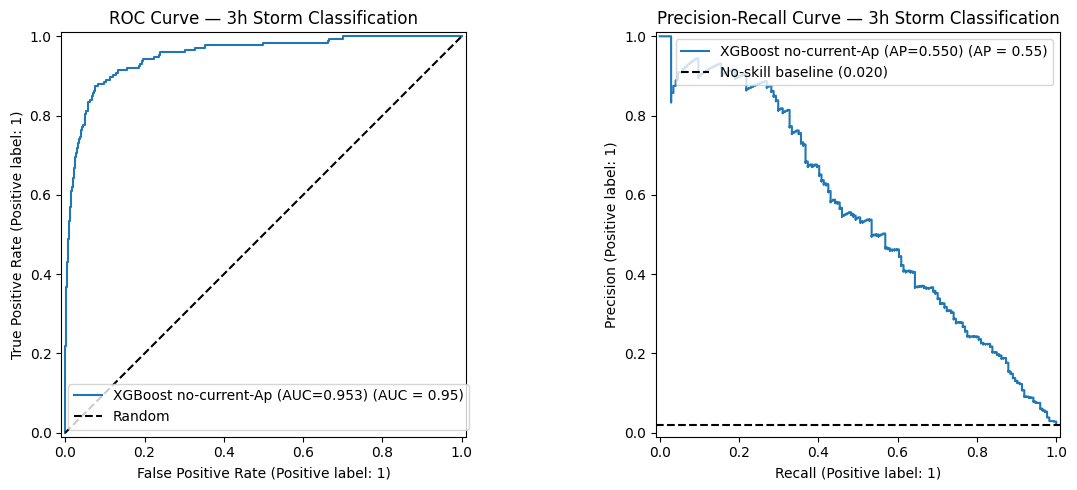

In [37]:
# ROC/PR Curve for no-current-Ap XGBoost classifier
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_predictions(
    y_test_class,
    y_pred_prob_no_ap,
    name=f"XGBoost no-current-Ap (AUC={roc_auc_no_ap:.3f})",
    ax=axes[0],
)
axes[0].plot([0, 1], [0, 1], "k--", label="Random")
axes[0].set_title("ROC Curve — 3h Storm Classification")
axes[0].legend()

PrecisionRecallDisplay.from_predictions(
    y_test_class,
    y_pred_prob_no_ap,
    name=f"XGBoost no-current-Ap (AP={pr_auc_no_ap:.3f})",
    ax=axes[1],
)
axes[1].axhline(
    y_test_class.mean(),
    color="k",
    linestyle="--",
    label=f"No-skill baseline ({y_test_class.mean():.3f})"
)
axes[1].set_title("Precision-Recall Curve — 3h Storm Classification")
axes[1].legend()

plt.tight_layout()
plt.show()

### ROC and Precision-Recall Curves

The no-current-Ap XGBoost classifier showed strong ranking performance for 3-hour-ahead storm prediction. The ROC-AUC was 0.953, indicating that the model generally ranked storm bins above non-storm bins well. The PR-AUC was 0.550, far above the no-skill baseline of 0.020, which is especially important because storm bins are rare.

The precision-recall curve is more informative than accuracy for this task because only about 2% of the test bins are storm events. The curve shows that the model contains useful signal, but threshold selection is still important because higher recall comes with more false alarms.

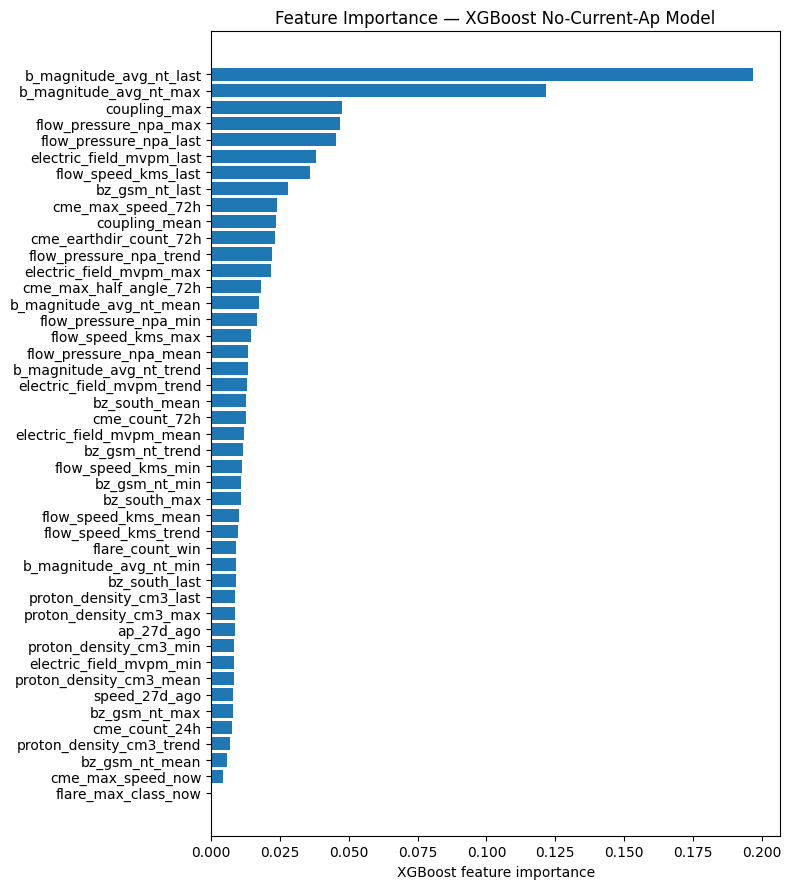


Top features:
b_magnitude_avg_nt_last     0.196788
b_magnitude_avg_nt_max      0.121559
coupling_max                0.047388
flow_pressure_npa_max       0.046796
flow_pressure_npa_last      0.045340
electric_field_mvpm_last    0.038026
flow_speed_kms_last         0.035922
bz_gsm_nt_last              0.027809
cme_max_speed_72h           0.023817
coupling_mean               0.023707
cme_earthdir_count_72h      0.023080
flow_pressure_npa_trend     0.022012
electric_field_mvpm_max     0.021555
cme_max_half_angle_72h      0.018240
b_magnitude_avg_nt_mean     0.017243


In [38]:
# feature importance plot
importances_no_ap = pd.Series(
    xgb_clf_no_ap_pipe.named_steps["model"].feature_importances_,
    index=FEATURE_COLS_NO_AP
).sort_values()

fig, ax = plt.subplots(figsize=(8, 9))
ax.barh(importances_no_ap.index, importances_no_ap.values)
ax.set_xlabel("XGBoost feature importance")
ax.set_title("Feature Importance — XGBoost No-Current-Ap Model")
plt.tight_layout()
plt.show()

print("\nTop features:")
print(importances_no_ap.tail(15).iloc[::-1].to_string())

### Feature Importance

For the no-current-Ap XGBoost model, the most important features were recent solar wind and magnetic field variables, including IMF magnitude, solar wind pressure, electric field, wind speed, Bz, coupling features, and CME activity over the previous 72 hours.

This supports the idea that the model is not relying only on current geomagnetic activity. Instead, it appears to use physically meaningful upstream solar wind and CME indicators for short-term storm classification. However, feature importance does not show causal direction, so these results should be interpreted as model behavior rather than proof that any single feature directly causes storms.

## Initial XGBoost Modeling Summary

This notebook used the 2010–2024 subset of the time-binned dataset, where each row represents a 3-hour time bin. We first evaluated XGBoost regression for 3-hour-ahead Ap prediction and compared it against a persistence baseline. The regression model slightly improved MAE during quiet periods, but it performed worse on storm bins, suggesting that plain regression still struggles with rare high-Ap spikes.

We then evaluated XGBoost classification for 3-hour-ahead storm prediction. The model performed strongly compared with the no-skill baseline, but current Ap features were among the most important predictors. To check whether the model was only learning short-term persistence, we trained a stricter version without current Ap features. This model still achieved strong ROC-AUC and PR-AUC, suggesting that solar wind, magnetic field, CME, and recurrence features contain useful predictive signal.

These results are promising but should be treated as initial baselines rather than final operational conclusions. Future work should test additional forecast horizons, tune thresholds and hyperparameters, compare against persistence at each horizon, and evaluate whether performance generalizes across different time periods and rare extreme storm events.